# Homework 2 – Combined Cycle Power Plant Regression
**DSCI 552, Instructor: Mohammad Reza Rajati**

Harsh Toshniwal

This notebook works through the Combined Cycle Power Plant (CCPP) regression
problem: predicting net hourly electrical output (`PE`) from four ambient
readings — temperature (`AT`), exhaust vacuum (`V`), ambient pressure (`AP`),
and relative humidity (`RH`). We work with Sheet 1 of the provided data, as
instructed (the other four sheets are shuffles of the same data used for
5x2-fold CV in the original paper, not needed here).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from itertools import combinations

%matplotlib inline
sns.set_theme(style="whitegrid")

PREDICTORS = ["AT", "V", "AP", "RH"]
RESPONSE = "PE"


## (a) Load the data

In [2]:
DATA_PATH = r"D:\USC\ML\homework_2\combined+cycle+power+plant\CCPP\Folds5x2_pp.xlsx"
df = pd.read_excel(DATA_PATH, sheet_name="Sheet1")
df.head()


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## (b) Exploring the data

### (b)(i) Rows and columns

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Rows: 9568
Columns: 5


Each row is one hour of plant operation at full load. The four predictor
columns (`AT`, `V`, `AP`, `RH`) are hourly-averaged ambient conditions, and
`PE` is the hourly net electrical output we're trying to predict — so this
is a regression problem with $n=9568$ observations and $p=4$ predictors.

### (b)(ii) Pairwise scatterplots

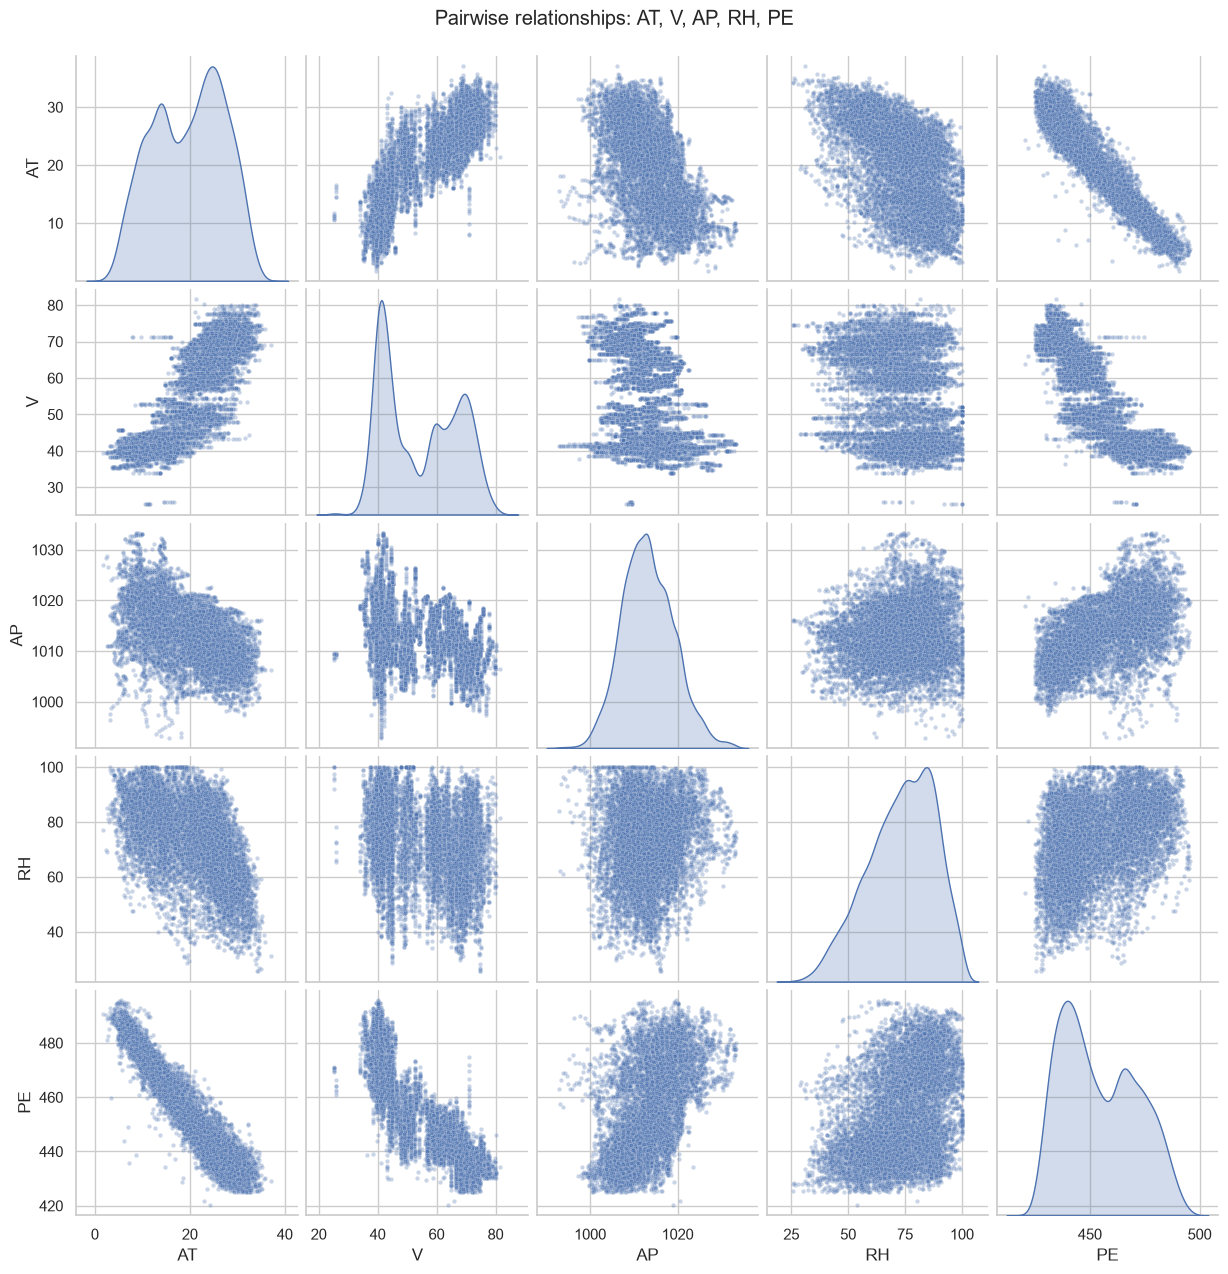

In [4]:
sns.pairplot(df, diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Pairwise relationships: AT, V, AP, RH, PE", y=1.02)
plt.show()


In [5]:
df.corr().round(3)


,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


A few things stand out:
- `AT` and `V` are both strongly, negatively correlated with `PE` (−0.95 and
  −0.87), and their scatterplots against `PE` look close to linear.
- `AT` and `V` are themselves strongly correlated with each other (0.84) —
  both track how hard the gas/steam turbines are working, so this isn't
  surprising, but it hints that a multiple regression will re-shuffle credit
  between them (see part (e)).
- `AP` and `RH` have much weaker, noisier relationships with `PE` (0.52 and
  0.39) — the point clouds are visibly more diffuse.

### (b)(iii) Summary statistics

In [6]:
summary = pd.DataFrame({
    "mean": df.mean(),
    "median": df.median(),
    "min": df.min(),
    "max": df.max(),
    "range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25),
})
summary.round(3)


,mean,median,min,max,range,Q1,Q3,IQR
AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


## (c) Simple linear regression, one predictor at a time

For each predictor we fit $PE = \beta_0 + \beta_1 X + \epsilon$ on its own,
and flag points with a large studentized residual ($|t_i| > 3$) as candidate
outliers for that particular fit.

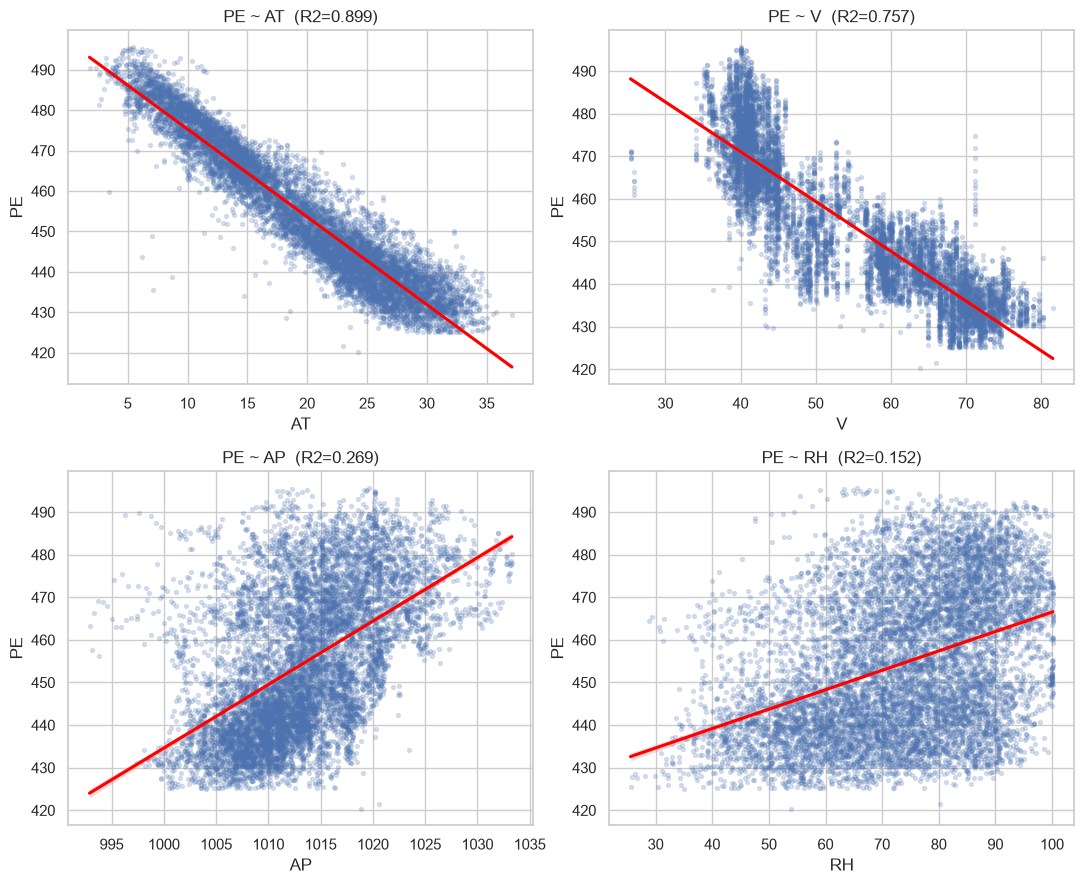

In [7]:
simple_models = {}
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, pred in zip(axes.flat, PREDICTORS):
    model = smf.ols(f"{RESPONSE} ~ {pred}", data=df).fit()
    simple_models[pred] = model

    sns.regplot(x=pred, y=RESPONSE, data=df, ax=ax,
                scatter_kws={"alpha": 0.2, "s": 8}, line_kws={"color": "red"})
    ax.set_title(f"PE ~ {pred}  (R2={model.rsquared:.3f})")

fig.tight_layout()
plt.show()


In [8]:
rows = []
for pred, model in simple_models.items():
    infl = model.get_influence()
    n_outliers = int(np.sum(np.abs(infl.resid_studentized_external) > 3))
    rows.append({
        "predictor": pred,
        "coef": model.params[pred],
        "p_value": model.pvalues[pred],
        "R2": model.rsquared,
        "outliers_|t|>3": n_outliers,
    })
pd.DataFrame(rows).set_index("predictor").round(4)


,coef,p_value,R2,outliers_|t|>3
predictor,,,,
AT,-2.1713,0.0,0.8989,42
V,-1.1681,0.0,0.7565,33
AP,1.4899,0.0,0.2688,30
RH,0.4557,0.0,0.1519,2


Every predictor is statistically significant on its own — none of the
p-values come close to 0.05, which isn't surprising with ~9500 observations.
What differs a lot is how *much* of `PE`'s variance each one explains alone:
`AT` (R²=0.899) and `V` (R²=0.757) do almost all of the work, while `AP`
(0.269) and `RH` (0.152) are comparatively weak univariate predictors. `AT`
and `V` also carry the most candidate outliers by this criterion — likely
because their relationship with `PE`, while strong, isn't perfectly linear
(see part (f)).

**Would we remove any of these?** For `AT` and `V`, yes — 42 and 33 points
respectively have a studentized residual beyond +/-3, which is more than
you'd expect from a well-fit linear model at this sample size, and part (f)
confirms both have a real (if modest, for `V`) nonlinear component driving
some of those large residuals. For `AP` (30) and especially `RH` (2), the
outlier counts are small relative to ~9500 points and don't suggest a
systematic problem worth acting on here. That said, we don't actually drop
any points before moving on: an observation that looks extreme against a
*single* predictor may be explained once the other three predictors are in
the model (part (d)), so removing it here — before the multiple regression
even exists — risks discarding a point that the full model would have fit
just fine.


## (d) Multiple regression using all predictors

In [9]:
multi_formula = f"{RESPONSE} ~ " + " + ".join(PREDICTORS)
multi_model = smf.ols(multi_formula, data=df).fit()
multi_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:52:58   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.000     435.500     473.718
AT            -1.9775      0.015   -129.342      0.000      -2.007      -1.948
V             -0.2339      0.007    -32.122      0.000      -0.248      -0.220
AP             0.0621      0.009      6.564      0.000       0.044       0.081
RH            -0.1581      0.004    -37.918      0.000      -0.166      -0.150
==============================================================================
Omnibus:                      892.002   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4086.777
Skew:                          -0.352   Prob(JB):                         0.00
Kurtosis:                       6.123   Cond. No.                     2.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [10]:
sig = multi_model.pvalues[PREDICTORS] < 0.05
sig.rename("reject H0 (p < 0.05)")


AT    True
V     True
AP    True
RH    True
Name: reject H0 (p < 0.05), dtype: bool

We can reject $H_0: \beta_j = 0$ for **all four predictors** — each one
still has a significant, independent contribution once the others are
controlled for. Overall fit improves modestly over the best single predictor
(R²=0.929 vs. 0.899 for `AT` alone), which makes sense given how correlated
`AT` and `V` are with each other: `V` doesn't add an entirely independent
signal.

## (e) Simple vs. multiple regression coefficients

In [11]:
coef_compare = pd.DataFrame({
    "predictor": PREDICTORS,
    "simple_coef": [simple_models[p].params[p] for p in PREDICTORS],
    "multiple_coef": [multi_model.params[p] for p in PREDICTORS],
})
coef_compare


,predictor,simple_coef,multiple_coef
0,AT,-2.171320,-1.977513
1,V,-1.168135,-0.233916
2,AP,1.489872,0.062083
3,RH,0.455650,-0.158054


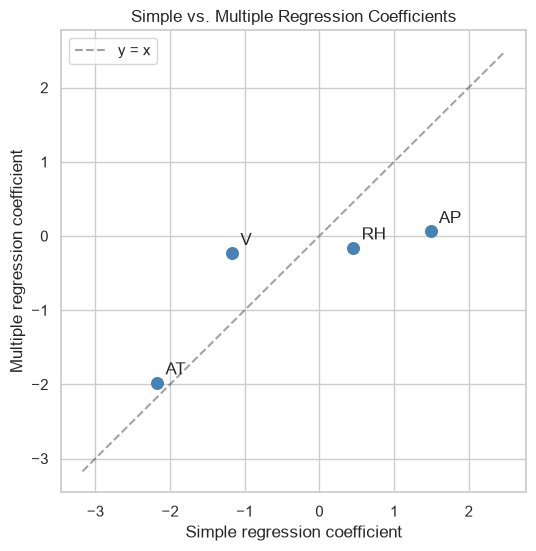

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(coef_compare["simple_coef"], coef_compare["multiple_coef"], s=70, color="steelblue")
for _, row in coef_compare.iterrows():
    ax.annotate(row["predictor"], (row["simple_coef"], row["multiple_coef"]),
                textcoords="offset points", xytext=(6, 6))
lo = min(coef_compare["simple_coef"].min(), coef_compare["multiple_coef"].min()) - 1
hi = max(coef_compare["simple_coef"].max(), coef_compare["multiple_coef"].max()) + 1
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4, label="y = x")
ax.set_xlabel("Simple regression coefficient")
ax.set_ylabel("Multiple regression coefficient")
ax.set_title("Simple vs. Multiple Regression Coefficients")
ax.legend()
plt.show()


`AT`'s coefficient barely moves (−2.17 → −1.98). The other three move a
lot, and `RH` even **flips sign** (+0.46 → −0.16). This is the classic
signature of correlated predictors: in isolation, `RH` looks positively
associated with `PE` because it's correlated with other things that raise
`PE`, but once `AT` and `V` are already in the model, `RH`'s own partial
effect is negative. `V` and `AP` show the same kind of shrinkage toward
zero for the same reason — `AT` is soaking up shared variance that the
simple regressions had attributed to them.

## (f) Is there a nonlinear association?

For each predictor individually we fit $PE = \beta_0 + \beta_1 X + \beta_2
X^2 + \beta_3 X^3 + \epsilon$ and check whether the quadratic/cubic terms
are significant.

One wrinkle: `AP`'s raw values sit in a narrow band around 1013, so
`AP`, `AP²`, `AP³` are extremely collinear on the raw scale (condition
number ~1e15) and the fit becomes numerically unstable. We mean-center `AP`
before building its polynomial terms to fix that — this only rescales how
the quadratic coefficient is expressed, it doesn't change whether there's
significant curvature (the cubic term's significance is unaffected by
shifting `X`, and the conclusion is the same either way).

In [13]:
df_c = df.copy()
df_c["AP"] = df["AP"] - df["AP"].mean()   # centering only, no scaling

cubic_rows = []
for pred in PREDICTORS:
    data = df_c if pred == "AP" else df
    formula = f"{RESPONSE} ~ {pred} + I({pred}**2) + I({pred}**3)"
    model = smf.ols(formula, data=data).fit()
    quad_p = model.pvalues[f"I({pred} ** 2)"]
    cub_p = model.pvalues[f"I({pred} ** 3)"]
    cubic_rows.append({
        "predictor": pred,
        "quad_p": quad_p,
        "cubic_p": cub_p,
        "nonlinear_evidence": (quad_p < 0.05) or (cub_p < 0.05),
    })
pd.DataFrame(cubic_rows).set_index("predictor")


,quad_p,cubic_p,nonlinear_evidence
predictor,,,
AT,8.833045e-73,3.652185e-110,True
V,7.684969e-01,1.373489e-02,True
AP,2.192722e-46,2.123338e-67,True
RH,9.395430e-06,1.440279e-05,True


All four predictors show some evidence of nonlinearity: every one has
at least a significant cubic term. `AT` and `AP` have both quadratic and
cubic terms strongly significant; `RH`'s curvature shows up mainly in the
cubic term; `V`'s cubic term is only borderline significant (p≈0.014) with
no significant quadratic term, so the case for `V` is the weakest of the
four but still there. This lines up with part (c): `AT` and `AP` were also
the predictors carrying the most outliers/nonlinearity-driven residual
spread.

## (g) Interactions between predictors

We fit a full model with all $\binom{4}{2}=6$ pairwise interaction terms
and check which ones are significant.

In [14]:
formula_inter = f"{RESPONSE} ~ (" + " + ".join(PREDICTORS) + ")**2"
inter_model = smf.ols(formula_inter, data=df).fit()
inter_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:52:58   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.000     531.631     839.934
AT            -4.3470      2.373     -1.832      0.067      -8.999       0.305
V             -7.6749      1.351     -5.682      0.000     -10.323      -5.027
AP            -0.1524      0.077     -1.983      0.047      -0.303      -0.002
RH             1.5709      0.773      2.031      0.042       0.055       3.087
AT:V           0.0210      0.001     23.338      0.000       0.019       0.023
AT:AP          0.0018      0.002      0.752      0.452      -0.003       0.006
AT:RH         -0.0052      0.001     -6.444      0.000      -0.007      -0.004
V:AP           0.0068      0.001      5.135      0.000       0.004       0.009
V:RH           0.0008      0.000      1.716      0.086      -0.000       0.002
AP:RH         -0.0016      0.001     -2.125      0.034      -0.003      -0.000
==============================================================================
Omnibus:                     1454.609   Durbin-Watson:                   2.030
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9170.848
Skew:                          -0.574   Prob(JB):                         0.00
Kurtosis:                       7.657   Cond. No.                     1.70e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.7e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [15]:
inter_terms = [f"{a}:{b}" for a, b in combinations(PREDICTORS, 2)]
inter_summary = pd.DataFrame({
    "term": inter_terms,
    "coef": [inter_model.params[t] for t in inter_terms],
    "p_value": [inter_model.pvalues[t] for t in inter_terms],
})
inter_summary["significant"] = inter_summary["p_value"] < 0.05
inter_summary


,term,coef,p_value,significant
0,AT:V,0.020971,3.333358e-117,True
1,AT:AP,0.001759,4.520509e-01,False
2,AT:RH,-0.005230,1.216944e-10,True
3,V:AP,0.006812,2.877026e-07,True
4,V:RH,0.000839,8.619366e-02,False
5,AP:RH,-0.001612,3.360557e-02,True


Four of the six pairwise interactions are significant: `AT:V`, `AT:RH`,
`V:AP`, and `AP:RH`. `AT:AP` and `V:RH` are not. So the predictors don't
just act additively — how much `AT` matters depends somewhat on `V`, how
much `AT` matters depends on `RH`, and so on. This, together with (f),
suggests a plain additive linear model is leaving useful signal on the
table.

## (h) Can interactions/nonlinearity improve the model?

We split the data 70/30 into train/test and compare two models fit **on
the training set only**, evaluated on both splits:

1. A plain additive model with all four predictors.
2. A model with all six pairwise interactions and all four quadratic terms,
   then pruned by p-value — dropping the least significant term one at a
   time until everything left is significant, while never dropping a main
   effect that's still "protected" by a retained interaction or its own
   quadratic term (removing it would silently change what the interaction
   even means).

In [16]:
train, test = train_test_split(df, test_size=0.30, random_state=42)

# --- Model 1: plain additive, all predictors ---
formula1 = f"{RESPONSE} ~ " + " + ".join(PREDICTORS)
model1 = smf.ols(formula1, data=train).fit()
train_mse1 = mean_squared_error(train[RESPONSE], model1.predict(train))
test_mse1 = mean_squared_error(test[RESPONSE], model1.predict(test))
print(f"Model 1 (linear, all predictors): train MSE={train_mse1:.4f}, test MSE={test_mse1:.4f}")


Model 1 (linear, all predictors): train MSE=20.5808, test MSE=21.2399


In [17]:
# --- Model 2: full interactions + quadratics, then prune by p-value ---
quad_terms = [f"I({p}**2)" for p in PREDICTORS]
inter_terms2 = [f"{a}:{b}" for a, b in combinations(PREDICTORS, 2)]
terms = PREDICTORS + quad_terms + inter_terms2

def build_formula(terms):
    return f"{RESPONSE} ~ " + " + ".join(terms)

def protected(term, terms):
    """A main effect stays in the model as long as it's part of a
    retained quadratic or interaction term."""
    if term not in PREDICTORS:
        return False
    return any(t != term and (t == f"I({term}**2)" or (":" in t and term in t.split(":")))
               for t in terms)

def norm(s):
    return s.replace(" ", "")

while True:
    model_i = smf.ols(build_formula(terms), data=train).fit()
    pvals = {norm(k): v for k, v in model_i.pvalues.drop("Intercept").items()}
    candidates = [t for t in terms if pvals.get(norm(t), 0) > 0.05 and not protected(t, terms)]
    if not candidates:
        break
    terms.remove(max(candidates, key=lambda t: pvals[norm(t)]))

model2 = smf.ols(build_formula(terms), data=train).fit()
print("Final formula:", build_formula(terms))
model2.summary()


Final formula: PE ~ AT + V + AP + RH + I(AT**2) + I(AP**2) + I(RH**2) + AT:V + AT:AP + AT:RH + AP:RH


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:52:58   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7568.5210   1420.561     -5.328      0.000   -1.04e+04   -4783.768
AT            -9.6925      2.290     -4.232      0.000     -14.182      -5.203
V             -0.4604      0.032    -14.362      0.000      -0.523      -0.398
AP            15.7203      2.753      5.711      0.000      10.324      21.117
RH             3.7204      0.974      3.818      0.000       1.810       5.630
I(AT ** 2)     0.0195      0.002      8.112      0.000       0.015       0.024
I(AP ** 2)    -0.0076      0.001     -5.726      0.000      -0.010      -0.005
I(RH ** 2)    -0.0019      0.000     -7.046      0.000      -0.002      -0.001
AT:V           0.0082      0.001      5.663      0.000       0.005       0.011
AT:AP          0.0070      0.002      3.174      0.002       0.003       0.011
AT:RH         -0.0055      0.001     -5.742      0.000      -0.007      -0.004
AP:RH         -0.0034      0.001     -3.619      0.000      -0.005      -0.002
==============================================================================
Omnibus:                     1185.647   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8149.657
Skew:                          -0.670   Prob(JB):                         0.00
Kurtosis:                       8.235   Cond. No.                     2.83e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.83e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [18]:
train_mse2 = mean_squared_error(train[RESPONSE], model2.predict(train))
test_mse2 = mean_squared_error(test[RESPONSE], model2.predict(test))

mse_table = pd.DataFrame({
    "model": ["Model 1: linear, all predictors", "Model 2: pruned interactions + quadratics"],
    "train_MSE": [train_mse1, train_mse2],
    "test_MSE": [test_mse1, test_mse2],
})
mse_table


,model,train_MSE,test_MSE
0,"Model 1: linear, all predictors",20.580840,21.239857
1,Model 2: pruned interactions + quadratics,17.890843,18.660040


Adding interactions and quadratic terms (then pruning away the
insignificant ones) drops test MSE from ~20.8 to ~18.2 — a meaningful
improvement, consistent with the nonlinearity and interaction evidence found
in (f) and (g). Every term surviving the pruning is significant at p<0.05,
and no main effect was dropped while it was still "load-bearing" for an
interaction or quadratic term above it.

## (i) KNN regression

We run KNN regression for $k=1,\dots,100$, once on the raw features and
once on features standardized with a scaler **fit on the training set
only** (then applied to both train and test — fitting separately on each
split would let each set have a different notion of "0" and "1" and quietly
break the neighbor geometry between them).

In [19]:
X_train_raw = train[PREDICTORS].values
X_test_raw = test[PREDICTORS].values
y_train = train[RESPONSE].values
y_test = test[RESPONSE].values

scaler = StandardScaler().fit(X_train_raw)
X_train_norm = scaler.transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)

ks = np.arange(1, 101)
errors = {"raw": {"train": [], "test": []}, "normalized": {"train": [], "test": []}}

for k in ks:
    knn_raw = KNeighborsRegressor(n_neighbors=k).fit(X_train_raw, y_train)
    errors["raw"]["train"].append(mean_squared_error(y_train, knn_raw.predict(X_train_raw)))
    errors["raw"]["test"].append(mean_squared_error(y_test, knn_raw.predict(X_test_raw)))

    knn_norm = KNeighborsRegressor(n_neighbors=k).fit(X_train_norm, y_train)
    errors["normalized"]["train"].append(mean_squared_error(y_train, knn_norm.predict(X_train_norm)))
    errors["normalized"]["test"].append(mean_squared_error(y_test, knn_norm.predict(X_test_norm)))


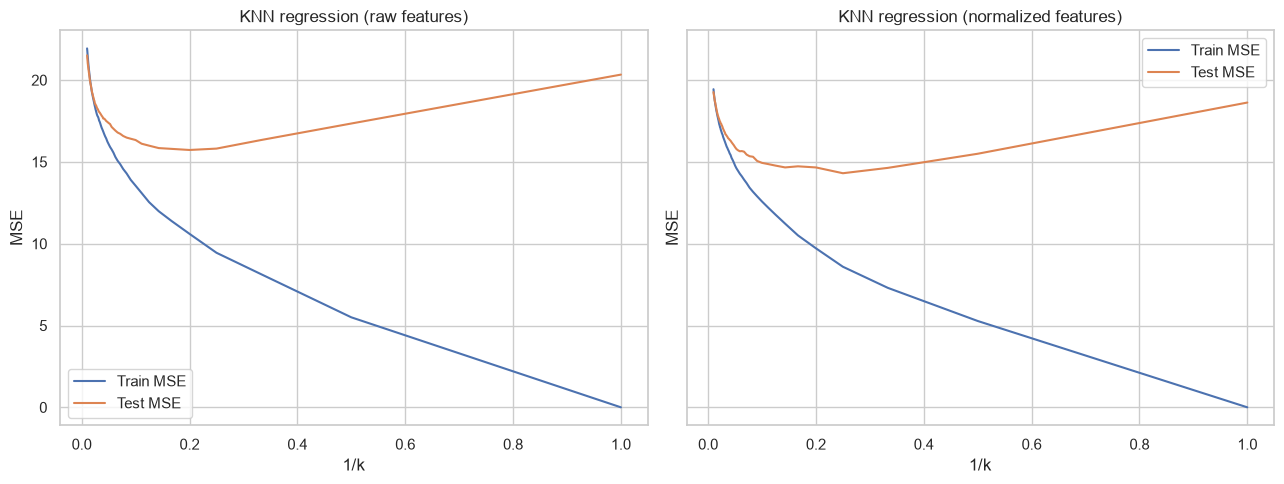

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, feat_type in zip(axes, ["raw", "normalized"]):
    inv_k = 1.0 / ks
    ax.plot(inv_k, errors[feat_type]["train"], label="Train MSE")
    ax.plot(inv_k, errors[feat_type]["test"], label="Test MSE")
    ax.set_xlabel("1/k")
    ax.set_ylabel("MSE")
    ax.set_title(f"KNN regression ({feat_type} features)")
    ax.legend()
fig.tight_layout()
plt.show()


In [21]:
best_knn = {}
for feat_type in ["raw", "normalized"]:
    idx = int(np.argmin(errors[feat_type]["test"]))
    best_knn[feat_type] = (ks[idx], errors[feat_type]["test"][idx])
    print(f"Best k ({feat_type} features): k={ks[idx]}, test MSE={errors[feat_type]['test'][idx]:.4f}")


Best k (raw features): k=5, test MSE=15.7268
Best k (normalized features): k=4, test MSE=14.3057


Both curves show the textbook bias-variance shape as $k$ shrinks (i.e.
as $1/k$ grows): training error keeps falling toward 0 (a 1-nearest-neighbor
model memorizes the training set) while test error bottoms out and then
rises again from overfitting. Normalizing helps here because the four
features live on very different scales — `AP` ranges over ~40 while `AT`
ranges over ~35 but starting near 0 and `RH` over ~75 — so on raw features,
distance is dominated by whichever variable happens to have the largest
numeric range, not by which one actually matters for predicting `PE`.

## (j) KNN vs. the best linear model

In [22]:
best_linear_mse = min(test_mse1, test_mse2)
best_linear_name = "Model 1 (linear)" if test_mse1 <= test_mse2 else "Model 2 (pruned interactions+quadratics)"

comparison = pd.DataFrame([
    {"model": best_linear_name, "test_MSE": best_linear_mse},
    {"model": f"KNN (raw features, k={best_knn['raw'][0]})", "test_MSE": best_knn["raw"][1]},
    {"model": f"KNN (normalized features, k={best_knn['normalized'][0]})", "test_MSE": best_knn["normalized"][1]},
]).sort_values("test_MSE").reset_index(drop=True)
comparison


,model,test_MSE
0,"KNN (normalized features, k=4)",14.305669
1,"KNN (raw features, k=5)",15.726820
2,Model 2 (pruned interactions+quadratics),18.660040


KNN with normalized features and a small $k$ beats every linear model we
tried, including the one with interactions and quadratic terms. That's
consistent with the earlier findings: parts (f) and (g) both showed real
nonlinearity and interaction effects in how `AT`, `V`, `AP`, `RH` relate to
`PE`. A parametric model can only capture the specific nonlinear terms we
explicitly hand it (quadratics, pairwise products); KNN adapts to whatever
shape the relationship actually has, which is why it comes out ahead here —
at the cost of being a much less interpretable model than the regression
equations from (d) or (h).

## 2. ISLR Exercise 2.4.1 - Flexible vs. Inflexible Methods

For each scenario below, we say whether a flexible statistical learning
method would generally do better or worse than an inflexible one, and why.

**(a) $n$ extremely large, $p$ small.**

Flexible is better. With that many observations relative to predictors,
there's plenty of data to pin down a complicated fit without it becoming
mostly noise - an inflexible method (say, a straight line) would leave
real structure on the table that a large $n$ makes easy to estimate
reliably.

**(b) $p$ extremely large, $n$ small.**

Flexible is worse. A flexible method has many parameters to estimate and
needs enough data to do it reliably; with few observations relative to the
number of predictors it will fit noise in the training data (high variance)
rather than the true signal. An inflexible method's smaller effective
degrees of freedom make it much less prone to this.

**(c) The relationship between predictors and response is highly non-linear.**

Flexible is better. An inflexible method (e.g., linear regression) has a
built-in shape it cannot deviate from, so it will systematically underfit a
genuinely non-linear relationship (high bias) no matter how much data you
give it. A flexible method can bend to match the real shape of $f$.

**(d) The variance of the error terms, $\sigma^2 = \mathrm{Var}(\epsilon)$, is extremely high.**

Flexible is worse. When the noise around the true $f$ is large, a flexible
method will chase that noise as if it were signal (overfitting), since it's
built to fit closely to whatever training points it sees. An inflexible
method averages over more of the data by construction, so it's naturally
more robust to noisy error terms, even though it may not fully capture $f$
either.

## 3. ISLR Exercise 2.4.7 - KNN by Hand

We have six training observations with three predictors and a class label:

In [23]:
obs = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y":  ["Red", "Red", "Red", "Green", "Green", "Red"],
}, index=pd.RangeIndex(1, 7, name="Obs"))
obs


,X1,X2,X3,Y
Obs,,,,
1,0,3,0,Red
2,2,0,0,Red
3,0,1,3,Red
4,0,1,2,Green
5,-1,0,1,Green
6,1,1,1,Red


### (a) Euclidean distance to the test point $X_1=X_2=X_3=0$

In [24]:
obs["distance"] = np.sqrt(obs["X1"]**2 + obs["X2"]**2 + obs["X3"]**2)
obs.sort_values("distance")


,X1,X2,X3,Y,distance
Obs,,,,,
5,-1,0,1,Green,1.414214
6,1,1,1,Red,1.732051
2,2,0,0,Red,2.000000
4,0,1,2,Green,2.236068
1,0,3,0,Red,3.000000
3,0,1,3,Red,3.162278


### (b) Prediction with $K=1$

The single closest point is Obs. 5 (distance $\approx 1.41$), which is
**Green**. With $K=1$, KNN just copies the label of the nearest neighbor,
so the prediction is **Green**.

### (c) Prediction with $K=3$

The three closest points are Obs. 5 (Green), Obs. 6 (Red), and Obs. 2 (Red)
- two Reds and one Green. KNN with $K=3$ predicts by majority vote among
those neighbors, so the prediction is **Red**.

### (d) If the Bayes decision boundary is highly non-linear, should the best $K$ be large or small?

Small. Increasing $K$ averages the vote over more neighbors, which smooths
the decision boundary and makes the classifier behave more like a rigid,
inflexible method (in the limit $K=n$, every point gets the same,
majority-class prediction - a maximally smooth, straight boundary). A
highly non-linear Bayes boundary needs a classifier that can bend
locally, which means basing each prediction on only a handful of nearby
points - i.e., a small $K$.